# Esperimento truths DM/SV scambiati

Estratto da `Likelihood.ipynb`, celle 103–113 (copiate senza modifiche, output inclusi).

## Setup comune

Copia delle celle 0, 1, 3, 4, 6, 7, 9 di `Likelihood.ipynb`: import, caricamento della pulsar J1640+2224 (DR2low), modello, likelihood, prior, likelihood jittata.

In [40]:
import numpy as np
import os, glob, json
import pickle

import sys

# this is the path to the discovery folder
sys.path.insert(0, "./")
import discovery_new as ds

import matplotlib.pyplot as plt
import scipy
import jax.numpy as jnp

from scipy.stats import uniform
import re
from PTMCMCSampler.PTMCMCSampler import PTSampler as ptmcmc
from scipy.stats import uniform
import jax

import time
import emcee

In [41]:
# path to the folder with the data
path = './dati/DR2low_feathers/'
s_dsfiles = np.sort(os.listdir(path))
psr = [ds.pulsar.Pulsar.read_feather(path + f'{psrfile}') for psrfile in s_dsfiles][9] # we are only analysing pulsar #9

In [43]:
# data
model = [psr.residuals]
# timing model
model += [ds.makegp_timing(psr, svd=True)]
# white noise parameters
model += [ds.makenoise_measurement(psr, psr.noisedict, tnequad = True, ecorr=True)]
# red noise paramters
model.append(ds.makegp_fourier(psr, ds.powerlaw, psr.noisedict[psr.name + '_red_components'], T=ds.getspan(psr), name='red_noise' ))
# DM variation parameters
model.append(ds.makegp_fourier(psr, ds.powerlaw, psr.noisedict[psr.name + '_dm_components'], T=ds.getspan(psr), name='dm_gp', fourierbasis=ds.make_dmfourierbasis(alpha = 2.0, tndm = False)))
# scattering noise parameters
model.append(ds.makegp_fourier(psr, ds.powerlaw, psr.noisedict[psr.name + '_chrom_components'], T=ds.getspan(psr), name='sv_gp', fourierbasis=ds.make_dmfourierbasis(alpha = 4.0, tndm = False)))

In [44]:
logL = ds.PulsarLikelihood(model).logL

In [46]:
# annoying function needed because the function logL want a dictionary as input, but our sampler wants a likelihood with an array as input
# so we have to switch from one to another :(
def params_dict_from_array(x):
    # ensure x is a plain numpy array before slicing
    x = np.asarray(x)
    return dict(zip(logL.params, x))

In [86]:
##### Cell for the prior distributions ###################################################################################

# dictionary with minimum and maximum value of the prior distribution
my_priordict = {}
my_priordict["(.*_)?sv_gp_gamma.*"] = [0, 7]
my_priordict["(.*_)?sv_gp_alpha.*"] = [0, 10]
my_priordict["(.*_)?sv_gp_log10_A.*"] = [-20, -11]
my_priordict["(.*_)?sw_log10_A.*"] = [-10, 1]
my_priordict["(.*_)?sw_gamma.*"] = [-5, 6]
my_priordict["(.*_)?dm_gp_gamma.*"] = [0, 7]
my_priordict["(.*_)?dm_gp_log10_A.*"] = [-20, -11]
my_priordict["(.*_)?red_noise_gamma.*"] = [0, 7]
my_priordict["(.*_)?red_noise_log10_A.*"] = [-20, -11]
my_priordict["(.*_)?sw_n_earth.*"] = [0, 30]


def build_priors(param_names, priordict):
    """
    Build a {param_name: scipy dist} dict with uniform prior distributions in the range
    """
    priors = {}
    unmatched = []
    for name in param_names:
        matched = False
        for pattern, (lo, hi) in priordict.items():
            if re.fullmatch(pattern, name):
                priors[name] = uniform(loc=lo, scale=hi - lo) ## this is where the uniform distribution is defined
                matched = True
                break
        if not matched:
            unmatched.append(name)

    if unmatched:
        print(f"Warning: no prior found for {len(unmatched)} parameters, "
              f"falling back to standard normal:\n  {unmatched}")
    return priors

priors = build_priors(logL.params, my_priordict)
priors

def log_prior(x):
    """Compute log prior"""
    params = params_dict_from_array(x)
    
    logp = 0.0
    for name, value in params.items():
        if name in priors:
            logp += priors[name].logpdf(value)
        else:
            # Default: standard normal prior
            if isinstance(value, np.ndarray):
                logp += -0.5 * np.sum(value**2)
            else:
                logp += -0.5 * value**2
    
    return logp

def prior_draw():
    """Draw from prior and return as flat array"""
    x = []
    for name in logL.params:
        x.append(priors[name].rvs())
    return np.array(x)

x0 = prior_draw()
x0

array([  1.41657955, -15.20565157,   3.04626604, -12.5891013 ,
         5.8842367 , -19.77807228])

In [49]:
@jax.jit # compile the likelihood in jax to make it faster
def _jit_logL(params_array):
    params = dict(zip(logL.params, params_array))
    return logL(params)

_jit_logL(x0)

def log_likelihood(x): 
    """
    Likelihood function that is given to the samples, it uses the jitted (=faster) version of the likelihood
    """
    x = np.asarray(x, dtype=np.float64)
    result = _jit_logL(jnp.array(x))
    return float(np.array(result))  # always a plain Python float

## Analisi (celle 103–113 dell'originale)

In [25]:
sim_gwb2_swap_psr = ds.pulsar.Pulsar.read_feather('sim_data_noiseGWB_swap_A145/J1640+2224')
print('nome     :', sim_gwb2_swap_psr.name)
print('N_TOA    :', len(sim_gwb2_swap_psr.toas))
print('shape M  :', sim_gwb2_swap_psr.Mmat.shape)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
nome     : J1640+2224
N_TOA    : 6777
shape M  : (6777, 39)


In [76]:
# analizzo i dati con GWB (A=-14.5, truths DM/SV invertiti) usando lo stesso modello a 6 par
model_sim_gwb2_swap = [sim_gwb2_swap_psr.residuals]
model_sim_gwb2_swap += [ds.makegp_timing(sim_gwb2_swap_psr, svd=True)]
model_sim_gwb2_swap += [ds.makenoise_measurement(sim_gwb2_swap_psr, sim_gwb2_swap_psr.noisedict, tnequad=True, ecorr=True)]
model_sim_gwb2_swap.append(ds.makegp_fourier(sim_gwb2_swap_psr, ds.powerlaw,
                                              sim_gwb2_swap_psr.noisedict[sim_gwb2_swap_psr.name + '_red_components'],
                                              T=ds.getspan(sim_gwb2_swap_psr), name='red_noise'))
model_sim_gwb2_swap.append(ds.makegp_fourier(sim_gwb2_swap_psr, ds.powerlaw,
                                              sim_gwb2_swap_psr.noisedict[sim_gwb2_swap_psr.name + '_dm_components'],
                                              T=ds.getspan(sim_gwb2_swap_psr), name='dm_gp',
                                              fourierbasis=ds.make_dmfourierbasis(alpha=2.0, tndm=False)))
model_sim_gwb2_swap.append(ds.makegp_fourier(sim_gwb2_swap_psr, ds.powerlaw,
                                              sim_gwb2_swap_psr.noisedict[sim_gwb2_swap_psr.name + '_chrom_components'],
                                              T=ds.getspan(sim_gwb2_swap_psr), name='sv_gp',
                                              fourierbasis=ds.make_dmfourierbasis(alpha=4.0, tndm=False)))

logL_sim_gwb2_swap = ds.PulsarLikelihood(model_sim_gwb2_swap).logL
logL_sim_gwb2_swap.params

TypeError: unsupported operand type(s) for ** or pow(): 'float' and 'NoneType'

In [84]:
# cella maledetta con alpha 
model_sim_gwb2_swap = [sim_gwb2_swap_psr.residuals]
model_sim_gwb2_swap += [ds.makegp_timing(sim_gwb2_swap_psr, svd=True)]
model_sim_gwb2_swap += [ds.makenoise_measurement(sim_gwb2_swap_psr, sim_gwb2_swap_psr.noisedict, tnequad=True, ecorr=True)]
model_sim_gwb2_swap.append(ds.makegp_fourier(sim_gwb2_swap_psr, ds.powerlaw,
                                              sim_gwb2_swap_psr.noisedict[sim_gwb2_swap_psr.name + '_red_components'],
                                              T=ds.getspan(sim_gwb2_swap_psr), name='red_noise'))
model_sim_gwb2_swap.append(ds.makegp_fourier(sim_gwb2_swap_psr, ds.powerlaw,
                                              sim_gwb2_swap_psr.noisedict[sim_gwb2_swap_psr.name + '_dm_components'],
                                              T=ds.getspan(sim_gwb2_swap_psr), name='dm_gp',
                                              fourierbasis=ds.make_dmfourierbasis(alpha=2.0, tndm=False)))
model_sim_gwb2_swap.append(ds.makegp_fourier(sim_gwb2_swap_psr, ds.powerlaw,
                                              sim_gwb2_swap_psr.noisedict[sim_gwb2_swap_psr.name + '_chrom_components'],
                                              T=ds.getspan(sim_gwb2_swap_psr), name='sv_gp',
                                              fourierbasis=ds.dmfourierbasis_alpha))

print(sim_gwb2_swap_psr, sim_gwb2_swap_psr.noisedict[sim_gwb2_swap_psr.name + '_chrom_components'])
logL_sim_gwb2_swap = ds.PulsarLikelihood(model_sim_gwb2_swap).logL
logL_sim_gwb2_swap.params

<Pulsar J1640+2224: 6777 res, 39 pars> 40


['J1640+2224_sv_gp_alpha',
 'J1640+2224_dm_gp_gamma',
 'J1640+2224_dm_gp_log10_A',
 'J1640+2224_red_noise_gamma',
 'J1640+2224_red_noise_log10_A',
 'J1640+2224_sv_gp_gamma',
 'J1640+2224_sv_gp_log10_A']

In [87]:
def params_dict_from_array_sim_gwb2_swap(x):
    x = np.asarray(x)
    return dict(zip(logL_sim_gwb2_swap.params, x))

priors_sim_gwb2_swap = build_priors(logL_sim_gwb2_swap.params, my_priordict)

def log_prior_sim_gwb2_swap(x):
    params = params_dict_from_array_sim_gwb2_swap(x)
    logp = 0.0
    for name, value in params.items():
        if name in priors_sim_gwb2_swap:
            logp += priors_sim_gwb2_swap[name].logpdf(value)
        else:
            logp += -0.5 * np.sum(np.asarray(value)**2)
    return logp

def prior_draw_sim_gwb2_swap():
    return np.array([priors_sim_gwb2_swap[name].rvs() for name in logL_sim_gwb2_swap.params])

x0_sim_gwb2_swap = prior_draw_sim_gwb2_swap()

In [91]:
print (x0_sim_gwb2_swap)

[  8.50509537   5.4941579  -17.3525307    5.16033668 -11.83827408
   2.34594297 -13.37194967]


In [88]:
@jax.jit
def _jit_logL_sim_gwb2_swap(params_array):
    return logL_sim_gwb2_swap(dict(zip(logL_sim_gwb2_swap.params, params_array)))

def log_likelihood_sim_gwb2_swap(x):
    x = np.asarray(x, dtype=np.float64)
    return float(np.array(_jit_logL_sim_gwb2_swap(jnp.array(x))))

print('logL iniziale =', log_likelihood_sim_gwb2_swap(x0_sim_gwb2_swap))

logL iniziale = -1356513.1811470748


In [92]:
sampler_sim_gwb2_swap = ptmcmc(
    ndim=len(logL_sim_gwb2_swap.params),
    logl=log_likelihood_sim_gwb2_swap,
    logp=log_prior_sim_gwb2_swap,
    cov=np.eye(len(logL_sim_gwb2_swap.params)) * 0.001,
    outDir='./test_sim_gwb_swap_A145alpha/',
    resume=True
)

In [93]:
print("Starting sampling (sim GWB A=-14.5, truths DM/SV invertiti)...")
sampler_sim_gwb2_swap.sample(x0_sim_gwb2_swap, Niter=1000000, thin=10)

Starting sampling (sim GWB A=-14.5, truths DM/SV invertiti)...
Finished 0.20 percent (0.20 percent of new work) in 117.304123 s Acceptance rate = 0.3005

KeyboardInterrupt: 

In [57]:
chain_sim_gwb2_swap = np.loadtxt('./test_sim_gwb_swap_A145/chain_1.txt')[:, :-4]
chain_sim_gwb2_swap = chain_sim_gwb2_swap[len(chain_sim_gwb2_swap)//4:]
chain_sim_gwb2_swap.shape   # atteso (~75000, 6)

(75001, 6)

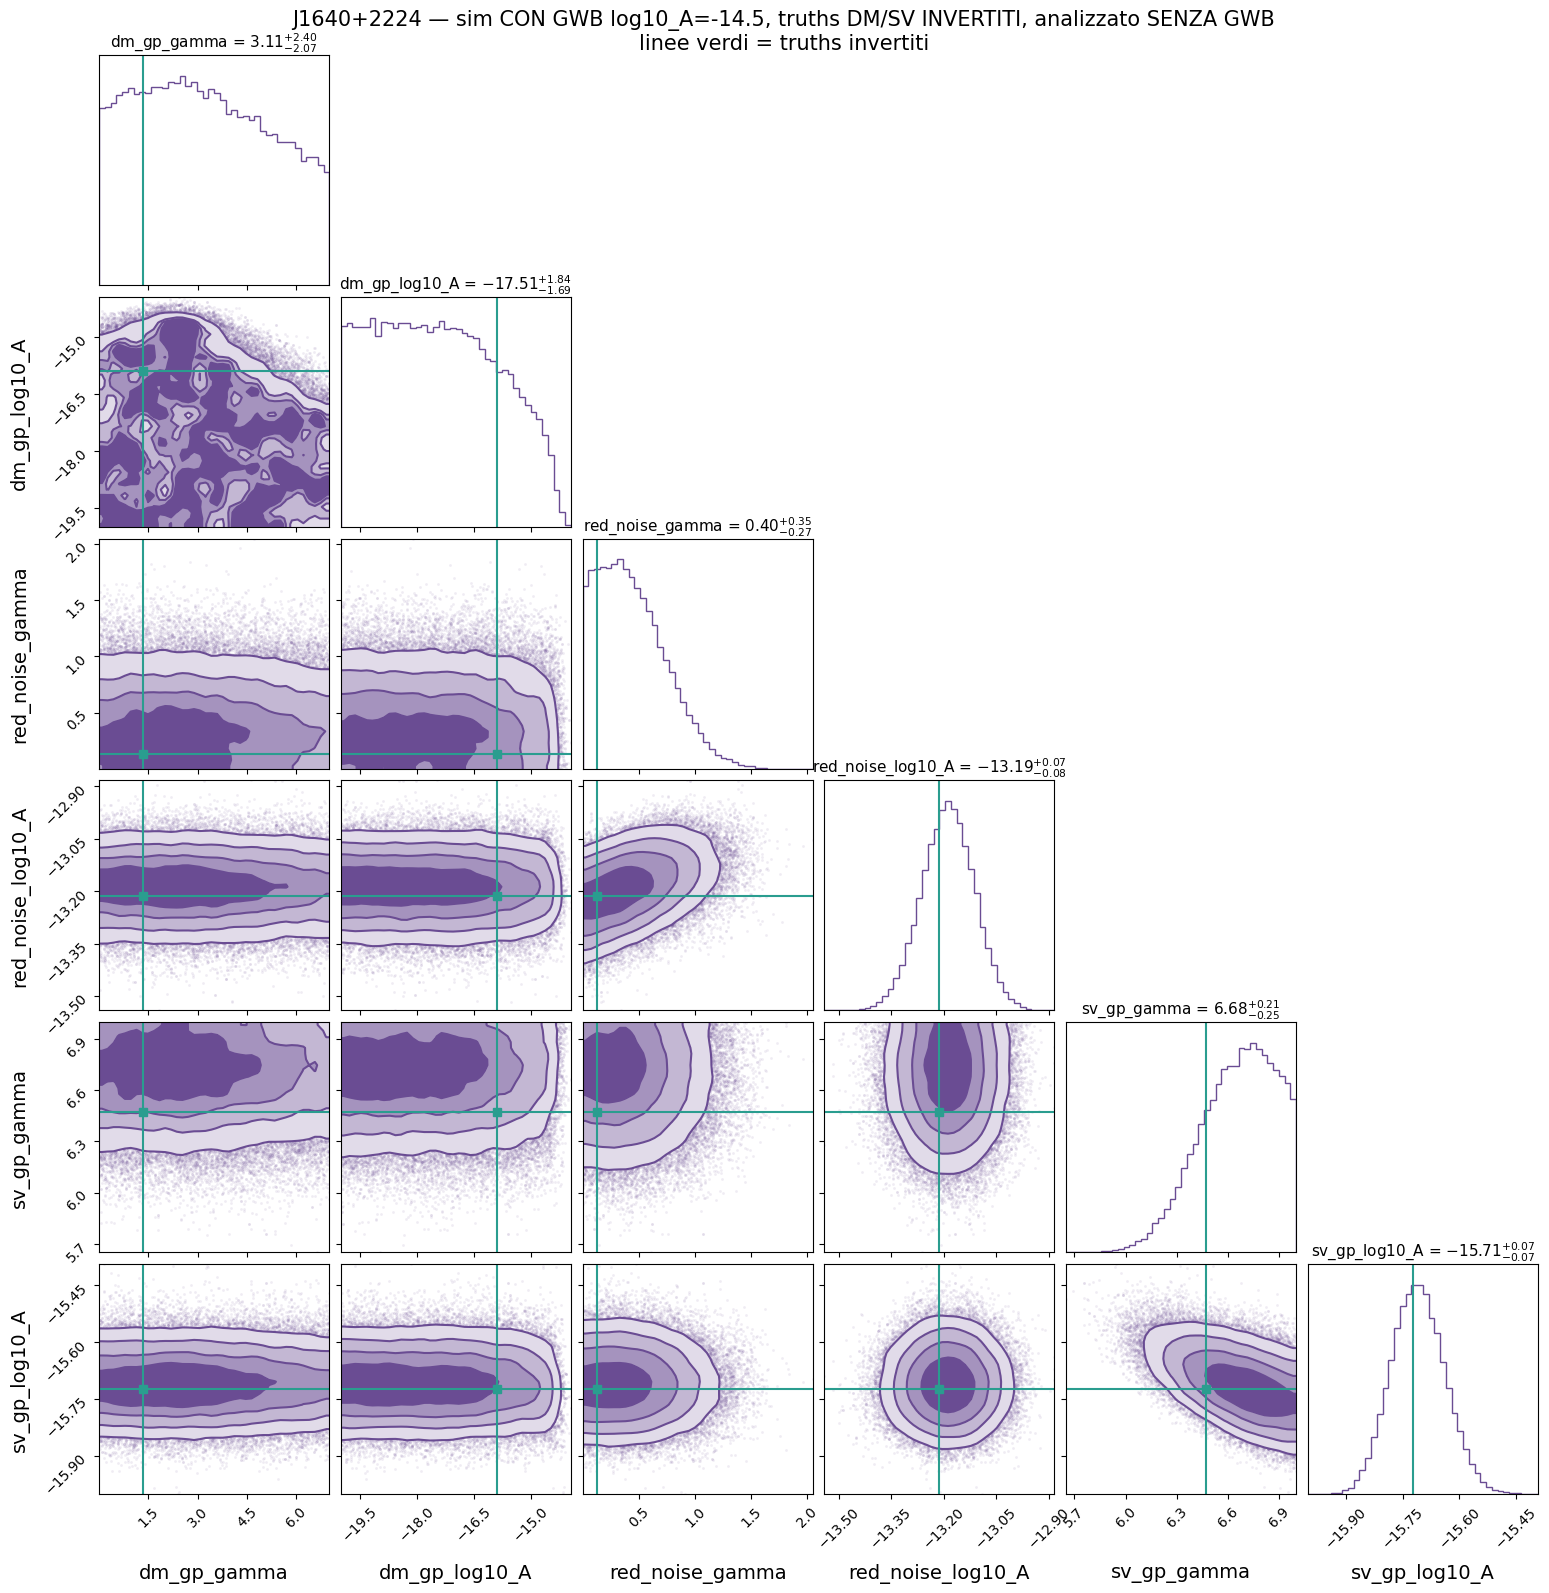

In [58]:
import corner
import numpy as np

# NOTA: truths INVERTITI tra DM e SV rispetto ai precedenti
truths_dict_swap = {
    'J1640+2224_dm_gp_gamma': 1.3259815720503758,
    'J1640+2224_dm_gp_log10_A': -15.888300265911965,
    'J1640+2224_red_noise_gamma': 0.13235259553929019,
    'J1640+2224_red_noise_log10_A': -13.212902548624186,
    'J1640+2224_sv_gp_gamma': 6.471070651479037,
    'J1640+2224_sv_gp_log10_A': -15.7227863246785,
}
truth_values_swap = [truths_dict_swap[p] for p in logL_sim_gwb2_swap.params]
clean_labels = [name.replace('J1640+2224_', '') for name in logL_sim_gwb2_swap.params]

fig = corner.corner(
    chain_sim_gwb2_swap[:],
    labels=clean_labels,
    truths=truth_values_swap,
    truth_color='#2A9D8F',
    show_titles=True,
    title_fmt='.2f',
    label_kwargs={'fontsize': 14},
    title_kwargs={'fontsize': 11},
    color='#6A4C93',
    fill_contours=True,
    levels=(0.39, 0.68, 0.86, 0.95),
    smooth=1.0, smooth1d=None,
    bins=40,
    hist_kwargs={"density": True}
)
fig.set_size_inches(16, 16)
fig.suptitle('J1640+2224 — sim CON GWB log10_A=-14.5, truths DM/SV INVERTITI, analizzato SENZA GWB\nlinee verdi = truths invertiti',
             fontsize=15, y=1.00)
fig.savefig('corner_sim_gwb_A145_swap.png', dpi=150, bbox_inches='tight')